In [14]:
import pandas as pd
import numpy as np
import joblib, os
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Drop Unnamed if exists
X_train = X_train.loc[:, ~X_train.columns.str.startswith('Unnamed')]
X_test  = X_test.loc[:, ~X_test.columns.str.startswith('Unnamed')]

print("Data loaded | Train:", X_train.shape, "| Test:", X_test.shape)

Data loaded | Train: (240122, 29) | Test: (60031, 29)


In [15]:
baseline = {
    'Model': 'Random Forest (baseline)',
    'MAE'  : 1759.56,
    'RMSE' : 3473.52,
    'R2'   : 0.9766
}
print("Baseline RF → R²: 0.9766 | MAE: ₹1,759")

Baseline RF → R²: 0.9766 | MAE: ₹1,759


In [16]:
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [10, 15, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
    'max_features'     : ['sqrt', 'log2'],
}

# Use 20% data for speed
X_search, _, y_search, _ = train_test_split(
    X_train, y_train,
    train_size=0.2,
    random_state=42
)

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
kfold   = KFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator          = rf_base,
    param_distributions= param_grid,
    n_iter             = 20,
    scoring            = 'r2',
    cv                 = kfold,
    verbose            = 2,
    random_state       = 42,
    n_jobs             = -1
)

print("Starting search... ⏳")
random_search.fit(X_search, y_search)
print("Done ✅")

print("\n🏆 Best Parameters:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\n📊 Best CV R²: {random_search.best_score_:.4f}")

Starting search... ⏳
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/Users/imamuddin/Desktop/ML-Projects/.conda/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/imamuddin/Desktop/ML-Projects/.conda/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/imamuddin/Desktop/ML-Projects/.conda/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ima

[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   7.1s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   7.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=300; total time=   8.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=300; total time=   8.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=300; total time=   8.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time=   8.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time=   8.6s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time=   8.7s
[CV] END max_depth=15, m

In [17]:
# ✅ Retrain on full data — not just 20%
best_model = RandomForestRegressor(
    **random_search.best_params_,
    random_state=42,
    n_jobs=-1
)
best_model.fit(X_train, y_train)

y_pred_tuned  = best_model.predict(X_test)
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_tuned)

mae  = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2   = r2_score(y_test_actual, y_pred_actual)

print(f"\n── Tuned Random Forest (Full Data) ──")
print(f"  MAE  : ₹{mae:,.0f}")
print(f"  RMSE : ₹{rmse:,.0f}")
print(f"  R²   : {r2:.4f}")


── Tuned Random Forest (Full Data) ──
  MAE  : ₹1,226
  RMSE : ₹2,887
  R²   : 0.9838


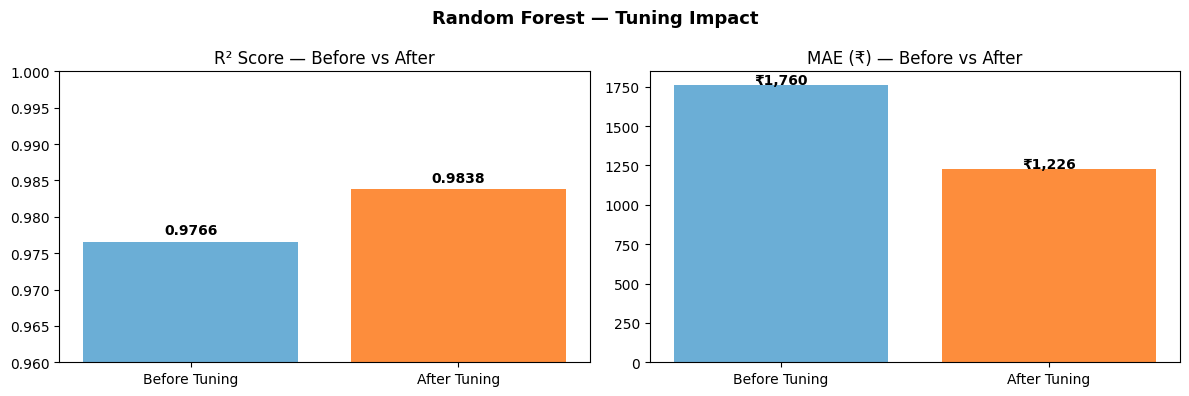

In [18]:
before_r2  = 0.9766
before_mae = 1759.56

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Before Tuning', 'After Tuning'],
            [before_r2, r2], color=['#6baed6', '#fd8d3c'])
axes[0].set_title('R² Score — Before vs After')
axes[0].set_ylim(0.96, 1.0)
for i, v in enumerate([before_r2, r2]):
    axes[0].text(i, v + 0.001, f"{v:.4f}", ha='center', fontweight='bold')

axes[1].bar(['Before Tuning', 'After Tuning'],
            [before_mae, mae], color=['#6baed6', '#fd8d3c'])
axes[1].set_title('MAE (₹) — Before vs After')
for i, v in enumerate([before_mae, mae]):
    axes[1].text(i, v + 10, f"₹{v:,.0f}", ha='center', fontweight='bold')

plt.suptitle('Random Forest — Tuning Impact', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

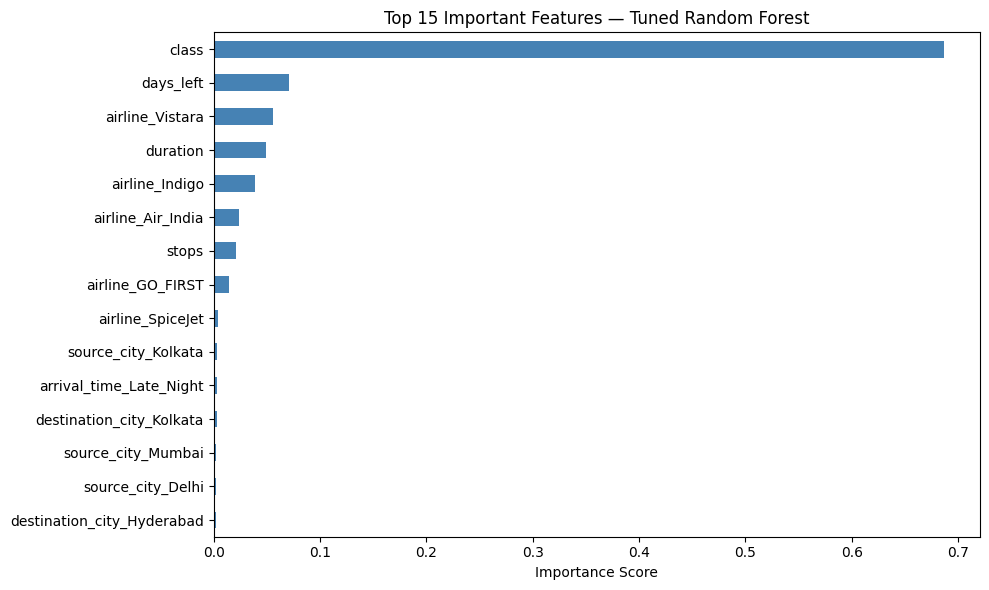

In [19]:
feat_imp     = pd.Series(best_model.feature_importances_, index=X_train.columns)
top_features = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.title('Top 15 Important Features — Tuned Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

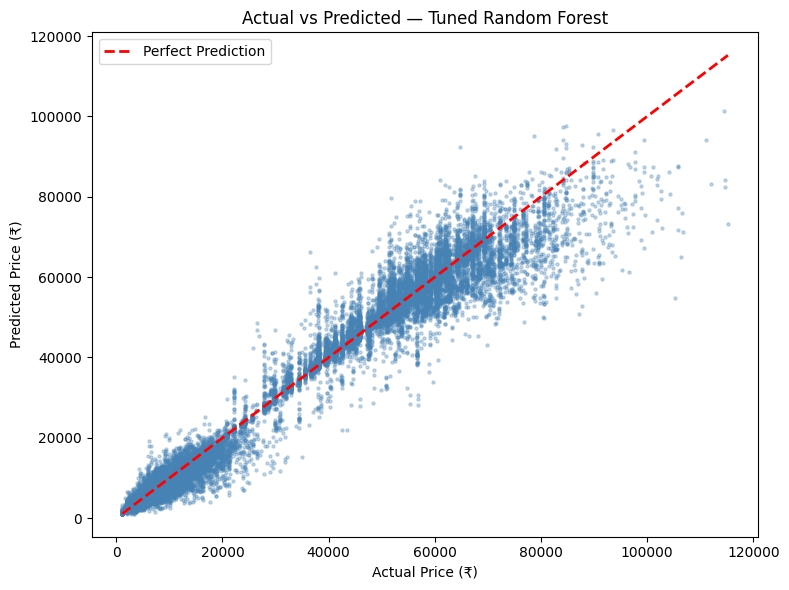

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.3, color='steelblue', s=5)
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price (₹)')
plt.ylabel('Predicted Price (₹)')
plt.title('Actual vs Predicted — Tuned Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
os.makedirs('../src', exist_ok=True)
joblib.dump(best_model, '../src/flight_price_model_tuned.pkl')
print("✅ Tuned model saved!")

✅ Tuned model saved!


In [22]:
model = joblib.load('../src/flight_price_model_tuned.pkl')
print(type(model))
# ✅ Should print: <class 'sklearn.ensemble._forest.RandomForestRegressor'>

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
